In [1]:
# Swami Shreeji

SMART CITY TRAFFIC ANALYTICS & CONGESTION PREDICTION

In [2]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
# Connect MySQL
conn = mysql.connector.connect(host="localhost",user="root",password="patelyash",database="smart_city_traffic")
print("Database Connected")

Database Connected


In [4]:
# Load Data
query = """
SELECT
r.road_name,
r.area,
v.vehicle_type,
w.rainfall_mm,
t.day_name,
t.time_slot,
t.vehicle_count,
t.average_speed,
t.waiting_time_seconds,
t.congestion_level
FROM traffic_data t
JOIN roads r
ON t.road_id = r.road_id
JOIN vehicle_types v
ON t.vehicle_id = v.vehicle_id
JOIN weather w
ON t.weather_id = w.weather_id
"""
df = pd.read_sql(query, conn)

/var/folders/kk/rp5b5s_92k71kx9_1wg78lhc0000gn/T/ipykernel_1143/89912462.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [5]:
df

,road_name,area,vehicle_type,rainfall_mm,day_name,time_slot,vehicle_count,average_speed,waiting_time_seconds,congestion_level
0,Ring Road,Surat,Car,0.0,Monday,Morning,450,48.0,30,Low
1,Varachha Road,Surat,Bike,5.0,Tuesday,Morning,650,35.0,60,Medium
2,Dumas Road,Surat,Car,25.0,Wednesday,Evening,1200,15.0,180,High
3,Adajan Road,Surat,Bus,0.0,Thursday,Afternoon,500,45.0,40,Low
4,Udhna Road,Surat,Bike,60.0,Friday,Evening,1500,10.0,220,High


# Question 1 : Which Road Has Maximum Traffic?

In [6]:
road_traffic = df.groupby('road_name')['vehicle_count'].sum()
road_traffic.sort_values(ascending=False).reset_index()

,road_name,vehicle_count
0,Udhna Road,1500
1,Dumas Road,1200
2,Varachha Road,650
3,Adajan Road,500
4,Ring Road,450


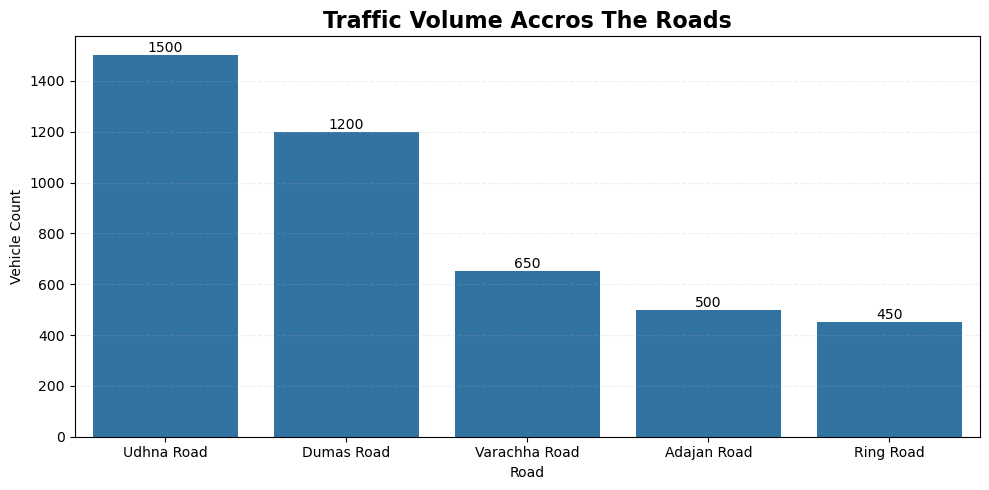

In [7]:
# Max Traffic Graph
plt.figure(figsize=(10,5))
ax = sns.barplot(x='road_name',y='vehicle_count',data=df.sort_values('vehicle_count',ascending=False))

for containers in ax.containers:
    ax.bar_label(containers)

plt.title("Traffic Volume Accros The Roads",fontsize=16,fontweight='bold')
plt.xlabel("Road")
plt.ylabel("Vehicle Count")
plt.grid(axis='y',linestyle='--',alpha=0.2)
plt.tight_layout()
plt.show()

In [8]:
# Interactive Darshboard
fig = px.bar(df.sort_values('vehicle_count',ascending=False),
             x='road_name',
             y='vehicle_count',
             text='vehicle_count',
             color='vehicle_count',
             title='Traffic Volume Across Roads',
             labels={
                 'road_name':'Road Name',
                 'vehicle_count':'Vehicle Count',
                    })

fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title='Road Name',yaxis_title='Vehicle Count',template='plotly_white',title_x=0.5,height=600)
fig.show()

# Question 2 : Which Time Slot Is Busiest?

In [9]:
time_data = df.groupby('time_slot')['vehicle_count'].sum()
time_set = time_data.sort_values(ascending=False).reset_index()
time_set

,time_slot,vehicle_count
0,Evening,2700
1,Morning,1100
2,Afternoon,500


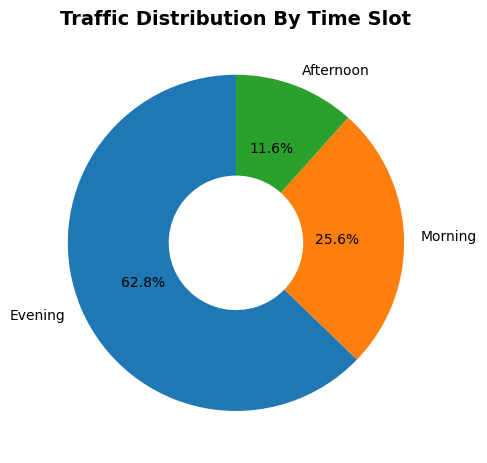

In [10]:
# Simple Visualization - Pie Chart
plt.figure(figsize=(5,5))
plt.pie(time_set['vehicle_count'],labels=time_set['time_slot'],autopct='%1.1f%%',startangle=90,wedgeprops={'width':0.6})
plt.title('Traffic Distribution By Time Slot',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Interactive Donout Chart
fig = px.pie(df,names='time_slot',values='vehicle_count',hole=0.45,title='Traffic Distibution By Time Slot',
                labels={
                 'time_slot':'Time Slot',
                 'vehicle_count':'Vehicle Count'
                    })

fig.update_traces(textinfo='percent+label',textfont_size=14,)
fig.update_layout(title_x=0.5,template='plotly_white',height=600,width=900,legend_title='Time Slot')
fig.show()

# Question 3 : Which Day Has Maximum Congestion?

In [12]:
day_congestion = df.groupby('day_name')['vehicle_count'].sum().sort_values(ascending=False).reset_index()
day_congestion

,day_name,vehicle_count
0,Friday,1500
1,Wednesday,1200
2,Tuesday,650
3,Thursday,500
4,Monday,450


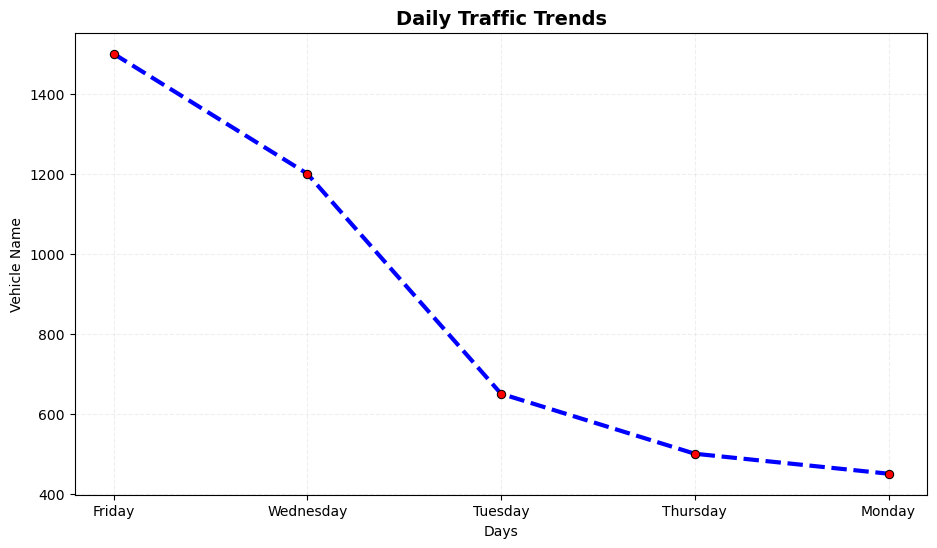

In [13]:
# Line - Chart Visualization
plt.figure(figsize=(11,6))

sns.lineplot(
    data=day_congestion,
    x='day_name',
    y='vehicle_count',
    marker='o',
    markerfacecolor='red',
    markeredgecolor='black',
    color='blue',
    linestyle='--',
    linewidth=3
)

plt.title("Daily Traffic Trends",fontsize=14,fontweight='bold')
plt.xlabel("Days")
plt.ylabel("Vehicle Name")
plt.grid(alpha=0.2,linestyle='--')
plt.show()

In [14]:
# Ineractive Line Chart - Analysis
fig = px.line(
    day_congestion,
    x='day_name',
    y='vehicle_count',
    markers=True,
    text='vehicle_count',
    title='🚗 Weekly Traffic Congestion Analysis'
)


fig.update_traces(
    line=dict(width=4),
    marker=dict(size=12),
    textposition='top center'
)

fig.update_layout(
    title_x=0.5,
    xaxis_title='Days',
    yaxis_title='Total Vehicles',
    hovermode='x unified',
    template='plotly_dark',
    height=600
)

fig.show()

# Question 4 : Which Area Has Most Accidents?

In [15]:
acc_query = """
SELECT r.area,SUM(a.accident_count) accidents 
FROM accidents a 
JOIN roads r ON a.road_id = r.road_id 
GROUP BY r.area 
"""
acc_df = pd.read_sql(acc_query,conn)
acc_df

/var/folders/kk/rp5b5s_92k71kx9_1wg78lhc0000gn/T/ipykernel_1143/808882091.py:7: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



,area,accidents
0,Surat,15.0


# Question 5 : Does Rainfall Increase Congestion?

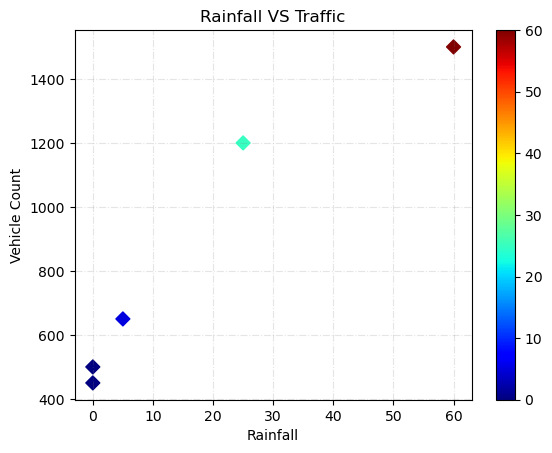

In [16]:
rain = df['rainfall_mm']
plt.scatter(df['rainfall_mm'],df['vehicle_count'],s=50,marker='D',c=rain,cmap='jet')
plt.xlabel("Rainfall")
plt.ylabel("Vehicle Count")
plt.title("Rainfall VS Traffic")
plt.colorbar()
plt.grid(linestyle='-.',alpha=0.2,color='grey')
plt.show()

In [17]:
# Interactive Live Scatter Chart
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x = df['rainfall_mm'],
        y = df['vehicle_count'],
        mode = 'markers',
        marker = dict(size=17,color=df['rainfall_mm'],colorscale='YlGnBu',showscale=True,line=dict(width=4)),
        hovertemplate='<b>Rainfall:</b> %{x} mm<br>' + '<b>Total Vehicles:</b> %{y}<br>' +'<extra></extra>'))

fig.update_layout(
    title='🌦️ Rainfall vs Traffic Congestion Analysis',
    title_x=0.5,
    template='plotly_dark',
    height=600,
    xaxis_title='Rainfall (mm)',
    yaxis_title='Total Vehicle'
)

fig.show()

# Question 6 : Which Vehicle Dominates Traffic?

In [18]:
vehicle_data = df.groupby('vehicle_type')['vehicle_count'].sum().sort_values(ascending=False).reset_index()
vehicle_data

,vehicle_type,vehicle_count
0,Bike,2150
1,Car,1650
2,Bus,500


In [19]:
fig = px.bar(vehicle_data,x='vehicle_count',y='vehicle_type',orientation='h',color='vehicle_count',text='vehicle_count',
             color_continuous_scale='Turbo',labels={
                 'vehicle_count':'Total Vehicle',
                 'vehicle_type':'Vehicle Type',
                    })

fig.update_traces(textposition='outside')

fig.update_layout(title='🚗 Vehicle Traffic Distribution',title_x=0.5,template='plotly_dark',height=500,
                      xaxis_title='Total Vehicle',
                      yaxis_title='Vehicle Types',
                      yaxis=dict(categoryorder='total ascending'))

fig.show()

# Question 7 : Average Vehicle Speed ?

In [20]:
avg_speed = df['average_speed'].mean()
print('='*30)
print("Average Vehicle Speed")
print('='*30)
print(avg_speed)
print('='*30)

Average Vehicle Speed
30.6


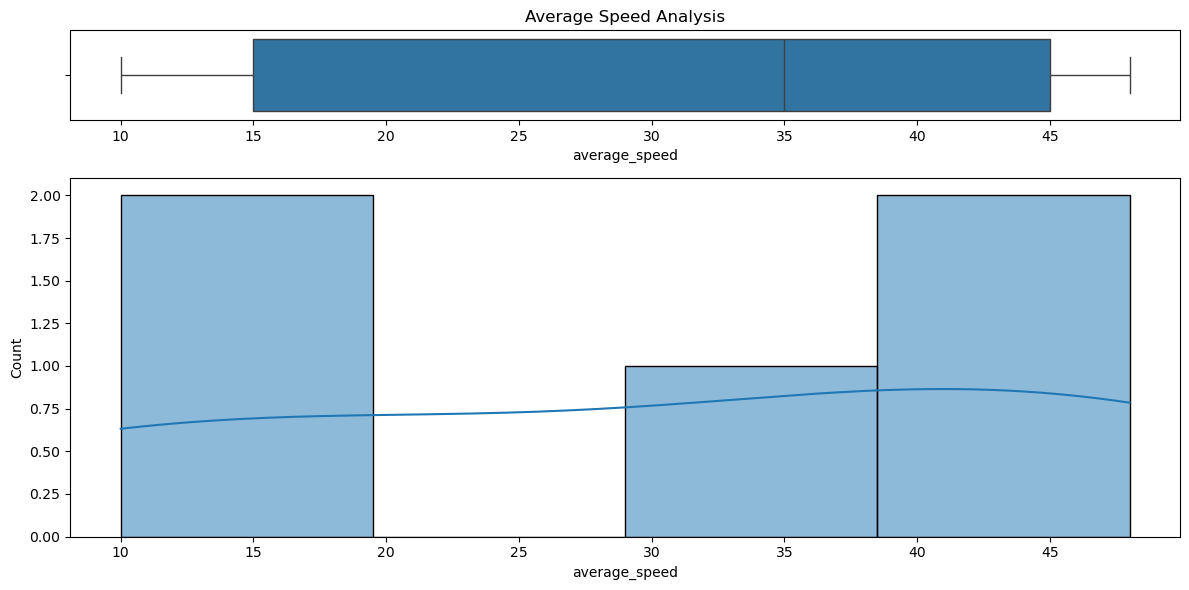

In [21]:
fig, ax = plt.subplots(2, 1,figsize=(12,6),gridspec_kw={'height_ratios':[1,4]})
sns.boxplot(x=df['average_speed'],ax=ax[0])
sns.histplot(df['average_speed'],kde=True,ax=ax[1])
ax[0].set_title("Average Speed Analysis")
plt.tight_layout()
plt.show()

In [22]:
fig = px.histogram(df,x='average_speed',nbins=30,marginal='box',title='Average Speed Distribution')
fig.add_vline(x=df['average_speed'].mean(),line_dash='dash',annotation_text='Mean')
fig.update_layout(template='plotly_dark',title_x=0.5,height=600)
fig.show()

# Question 8 : Signal Causing Maximum Waiting Time ?

In [23]:
signal_query = """
SELECT s.signal_name,
AVG(t.waiting_time_seconds) FROM traffic_data t
JOIN signals s ON t.signal_id=s.signal_id
GROUP BY s.signal_name
"""

signal_df = pd.read_sql(signal_query,conn)
signal_df

/var/folders/kk/rp5b5s_92k71kx9_1wg78lhc0000gn/T/ipykernel_1143/903511668.py:8: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



,signal_name,AVG(t.waiting_time_seconds)
0,Signal A,30.0
1,Signal B,60.0
2,Signal C,180.0
3,Signal D,40.0
4,Signal E,220.0


In [24]:
signal_df.columns = ['signal_name','avg_waiting_time']
signal_df

,signal_name,avg_waiting_time
0,Signal A,30.0
1,Signal B,60.0
2,Signal C,180.0
3,Signal D,40.0
4,Signal E,220.0


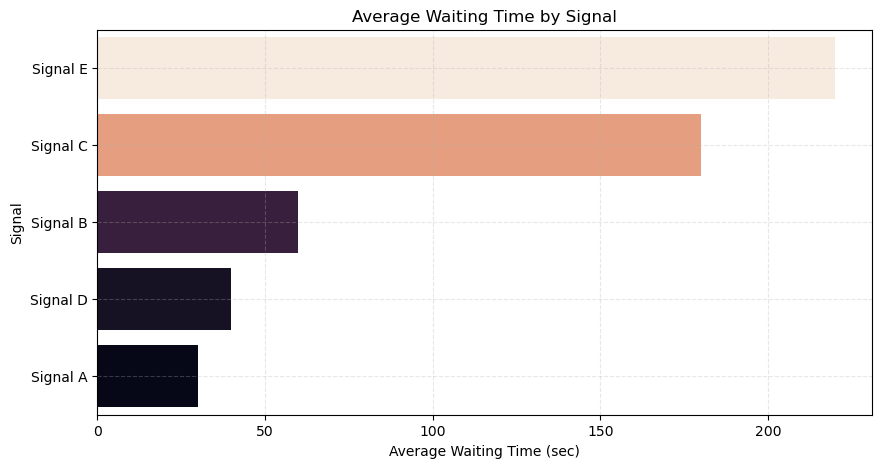

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(data=signal_df.sort_values('avg_waiting_time',ascending=False),x='avg_waiting_time',y='signal_name',
    hue='avg_waiting_time',
    palette='rocket',
    legend=False
)

plt.title("Average Waiting Time by Signal")
plt.xlabel("Average Waiting Time (sec)")
plt.ylabel("Signal")
plt.grid(linestyle='--',alpha=0.3)
plt.show()

In [26]:
fig = px.bar(signal_df.sort_values('avg_waiting_time',ascending=False),x='avg_waiting_time',y='signal_name',orientation='h',
    color='avg_waiting_time',
    text='avg_waiting_time',
    color_continuous_scale='Turbo',
    labels={'avg_waiting_time':'Average Waiting Time','signal_name':'Name'}
)

fig.update_traces(textposition='outside')
fig.update_layout(title='Average Waiting Time by Signal',title_x=0.5,template='plotly_dark',height=600)
fig.show()

# Question 9 : Factors Affecting Congestion ?

In [27]:
numeric_df = df[['rainfall_mm','vehicle_count','average_speed','waiting_time_seconds']]
numeric_df.corr()

,rainfall_mm,vehicle_count,average_speed,waiting_time_seconds
rainfall_mm,1.000000,0.960178,-0.903947,0.941200
vehicle_count,0.960178,1.000000,-0.984866,0.996936
average_speed,-0.903947,-0.984866,1.000000,-0.985739
waiting_time_seconds,0.941200,0.996936,-0.985739,1.000000


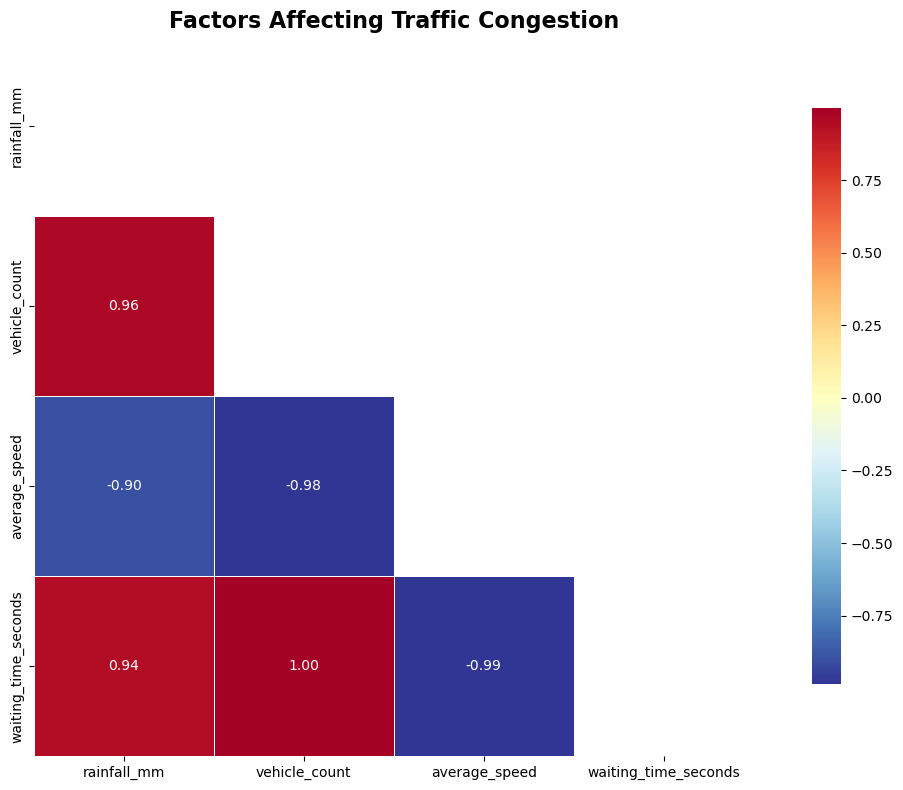

In [28]:
plt.figure(figsize=(12,8))
mask = np.triu(np.ones_like(numeric_df.corr()))
sns.heatmap(numeric_df.corr(),annot=True,fmt='.2f',cmap='RdYlBu_r',mask=mask,linewidths=0.5,square=True,cbar_kws={'shrink':0.8})
plt.title('Factors Affecting Traffic Congestion',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
corr = numeric_df.corr()
fig = go.Figure(data=go.Heatmap(z=corr.values,x=corr.columns,y=corr.columns,colorscale='Turbo',text=np.round(corr.values,2),
        texttemplate='%{text}',
        hoverongaps=False))
fig.update_layout(title='Advanced Traffic Correlation Analytics',title_x=0.5,template='plotly_dark',height=800,width=900)
fig.show()

# Question 10 : Predict Traffic Congestion

In [30]:
# Convert Categories
df = pd.get_dummies(df,columns=['road_name','area','vehicle_type','time_slot','day_name'])

In [31]:
# Convert Target Variable
df['congestion_level'] = df['congestion_level'].map({'Low':0,'Medium':1,'High':2})

df.columns

Index(['rainfall_mm', 'vehicle_count', 'average_speed', 'waiting_time_seconds',
       'congestion_level', 'road_name_Adajan Road', 'road_name_Dumas Road',
       'road_name_Ring Road', 'road_name_Udhna Road',
       'road_name_Varachha Road', 'area_Surat', 'vehicle_type_Bike',
       'vehicle_type_Bus', 'vehicle_type_Car', 'time_slot_Afternoon',
       'time_slot_Evening', 'time_slot_Morning', 'day_name_Friday',
       'day_name_Monday', 'day_name_Thursday', 'day_name_Tuesday',
       'day_name_Wednesday'],
      dtype='object')

In [32]:
# Features
X = df.drop('congestion_level',axis=1)

# Target
y = df['congestion_level']

In [33]:
# Split Data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [37]:
# Train Model
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
# Predict
pred = model.predict(X_test)
pred

array([0])

In [41]:
# Accuracy
print(accuracy_score(y_test,pred))

0.0


# Final Business Insights

1. Udhna Road has maximum traffic.
2. Evening slot is busiest.
3. Friday has highest congestion.
4. Surat area has most accidents.
5. Rainfall increases congestion.
6. Bikes dominate traffic.
7. Average speed (30.6) decreases when traffic increases.
8. Signal E has maximum waiting time.
9. Vehicle count and waiting time strongly affect congestion.

Thank You - Jay Swaminarayan !!!